## Genetic Algorithms

Genetic algorithms are a type of optimization algorithm inspired by the process of natural selection. They are used to find optimal or near-optimal solutions to complex problems by mimicking the process of evolution.

The stages of a genetic algorithm typically include:
1. **Initialization**: A population of candidate solutions (called individuals) is generated randomly or based on some heuristic.

2. **Selection**: Individuals are selected from the population based on their fitness, which is a measure of how well they solve the problem at hand.

3. **Crossover**: Selected individuals are paired and combined to create offspring, which may inherit traits from both parents.

4. **Mutation**: Offspring may undergo random changes to introduce variation into the population.

5. **Replacement**: The new generation of individuals replaces the old population, and the process repeats until a stopping criterion is met (e.g., a solution is found, a maximum number of generations is reached, or the population converges).

In [1]:
# Genetic Algorithms: One-Max Problem
# Single-Point Crossover
import random

def random_genome(string_length):
    # Generate a random string with a given length
    return [random.choice([0, 1]) for _ in range(string_length)]

In [2]:
def fitness(genome):
    # Find fitness: The number of 1s in the string
    fitness_list = []
    for i in range(len(genome)):
        genome_one = [genome[i][j] for j in range(len(genome[i]))
                      if genome[i][j] == 1]
        fitness = len(genome_one)
        fitness_list.append(fitness)
    return fitness_list

In [3]:
def choose_parent(genome, top_parents):
    fitness_list = fitness(genome)
    merged_list = [(genome[i], fitness_list[i]) for i in range(len(genome))]
    sorted_list = sorted(merged_list, key=lambda x: x[1], reverse=True)
    return sorted_list[:top_parents]

In [4]:
def crossover(genome, top_parents):
    parent1, parent2 = choose_parent(genome, top_parents)
    parent1, parent2 = parent1[0], parent2[0]

    cross_point = random.randint(0, len(genome))

    offspring1 = parent1[:cross_point] + parent2[cross_point:]
    offspring2 = parent2[:cross_point] + parent1[cross_point:]

    return offspring1, offspring2

In [5]:
def mutation(genome, top_parents, mutation_rate):
    offspring1, offspring2 = crossover(genome, top_parents)

    offspring1_flip = [bit if random.random() > mutation_rate else 1 - bit
                       for bit in offspring1]
    offspring2_flip = [bit if random.random() > mutation_rate else 1 - bit
                       for bit in offspring2]

    return offspring1_flip, offspring2_flip

In [6]:
def new_generation(genome, top_parents, mutation_rate):
    fitness_list = fitness(genome)
    offspring1, offspring2 = list(mutation(genome, top_parents, mutation_rate))

    merged_list = [(genome[i], fitness_list[i]) for i in range(len(genome))]
    sorted_list = sorted(merged_list, key=lambda x: x[1], reverse=True)

    sorted_genome = [gen[0] for gen in sorted_list]

    top_genome = [offspring1] + [offspring2]
    sorted_genome = top_genome + [
        geno for geno in sorted_genome if geno not in sorted_genome[:top_parents]
    ]

    return sorted_genome

In [7]:
def is_solution_found(genome, string_length):
    for g in genome:
        if sum(g) == string_length:
            return True, g
    return False, []

In [8]:
def main():
    print("One Max Problem")

    string_length = 5
    population_size = 4
    mutation_rate = 1 / string_length
    generations = 100
    top_parents = 2

    genome = [random_genome(string_length) for _ in range(population_size)]

    for gen in range(generations):
        print(f"\nGeneration {gen + 1}:")
        for i, individual in enumerate(genome):
            print(f"- {i+1}: {individual} | Fitness: {sum(individual)}")

        found, solution = is_solution_found(genome, string_length)

        if found:
            print(f"\nSolution found in generation {gen + 1}: {solution}")
            break

        genome = new_generation(genome, top_parents, mutation_rate)

    else:
        print("\nSolution not found within the generation limit.")


if __name__ == "__main__":
    main()

One Max Problem

Generation 1:
- 1: [1, 0, 0, 0, 0] | Fitness: 1
- 2: [1, 0, 1, 1, 1] | Fitness: 4
- 3: [1, 0, 0, 1, 1] | Fitness: 3
- 4: [1, 1, 0, 1, 0] | Fitness: 3

Generation 2:
- 1: [0, 1, 1, 1, 0] | Fitness: 3
- 2: [1, 0, 1, 1, 0] | Fitness: 3
- 3: [1, 1, 0, 1, 0] | Fitness: 3
- 4: [1, 0, 0, 0, 0] | Fitness: 1

Generation 3:
- 1: [0, 0, 1, 1, 0] | Fitness: 2
- 2: [1, 0, 1, 1, 0] | Fitness: 3
- 3: [1, 1, 0, 1, 0] | Fitness: 3
- 4: [1, 0, 0, 0, 0] | Fitness: 1

Generation 4:
- 1: [1, 0, 1, 1, 1] | Fitness: 4
- 2: [1, 1, 0, 1, 1] | Fitness: 4
- 3: [0, 0, 1, 1, 0] | Fitness: 2
- 4: [1, 0, 0, 0, 0] | Fitness: 1

Generation 5:
- 1: [1, 0, 1, 0, 1] | Fitness: 3
- 2: [1, 1, 0, 1, 1] | Fitness: 4
- 3: [0, 0, 1, 1, 0] | Fitness: 2
- 4: [1, 0, 0, 0, 0] | Fitness: 1

Generation 6:
- 1: [1, 1, 1, 0, 1] | Fitness: 4
- 2: [0, 0, 1, 0, 1] | Fitness: 2
- 3: [0, 0, 1, 1, 0] | Fitness: 2
- 4: [1, 0, 0, 0, 0] | Fitness: 1

Generation 7:
- 1: [0, 1, 1, 0, 1] | Fitness: 3
- 2: [1, 1, 1, 1, 1] | Fitnes

Knapsack Problem Example:

In [9]:
items = [[7, 5], [2, 4], [1, 7], [9, 2], [5, 1], [3, 3]]
capacity = 15
generations = 100
population_size = 10
mutation_rate = 0.05

In [10]:
import random

def initial_population(items):
    return [random.choice([0, 1]) for _ in range(len(items))]

In [11]:
def fitness(genomes):
    fitness_list = []

    genomes_weight = [[items[j][0] if genomes[i][j] == 1 else 0
                       for j in range(len(genomes[i]))]
                      for i in range(len(genomes))]

    genomes_profit = [[items[j][1] if genomes[i][j] == 1 else 0
                       for j in range(len(genomes[i]))]
                      for i in range(len(genomes))]

    for gen in range(len(genomes)):
        total_weight = sum(genomes_weight[gen])
        total_profit = sum(genomes_profit[gen])

        if capacity >= total_weight > 0:
            fitness_list.append((genomes[gen], total_profit))

    return fitness_list

In [12]:
def reproduction(genomes):
    fitness_list = fitness(genomes)
    sorted_list = sorted(fitness_list, key=lambda x: x[1], reverse=True)
    top_parents = max(2, len(sorted_list) // 10)

    return sorted_list[:top_parents]

In [13]:
def crossover(genomes):
    parents = reproduction(genomes)
    parents = [parent[0] for parent in parents]

    offspring = []

    while len(offspring) < int(population_size * 0.9):
        parent1, parent2 = random.sample(parents, 2)

        child = [parent1[i] if random.random() < 0.5 else parent2[i]
            for i in range(len(parent1))]

        mutated_child = mutation(child, mutation_rate)

        offspring.append(mutated_child)

    return offspring

In [14]:
def mutation(genomes, mutation_rate):
    return [bit if random.random() > mutation_rate else 1 - bit
        for bit in genomes]

Knapsack Problem: Genetic Algorithm
Generation 1: Best Profit = 17, Solution = [1, 1, 1, 0, 1, 0]
Average Fitness 9.4
Generation 2: Best Profit = 15, Solution = [0, 1, 1, 0, 1, 1]
Average Fitness 10.0
Generation 3: Best Profit = 16, Solution = [0, 1, 1, 1, 0, 1]
Average Fitness 13.666666666666666
Generation 4: Best Profit = 16, Solution = [0, 1, 1, 1, 0, 1]
Average Fitness 13.666666666666666
Generation 5: Best Profit = 16, Solution = [0, 1, 1, 1, 0, 1]
Average Fitness 13.571428571428571
Generation 6: Best Profit = 16, Solution = [0, 1, 1, 1, 0, 1]
Average Fitness 14.666666666666666
Generation 7: Best Profit = 16, Solution = [0, 1, 1, 1, 0, 1]
Average Fitness 16.0
Generation 8: Best Profit = 16, Solution = [0, 1, 1, 1, 0, 1]
Average Fitness 13.666666666666666
Generation 9: Best Profit = 16, Solution = [0, 1, 1, 1, 0, 1]
Average Fitness 15.222222222222221
Generation 10: Best Profit = 16, Solution = [0, 1, 1, 1, 0, 1]
Average Fitness 15.222222222222221
Generation 11: Best Profit = 16, Sol

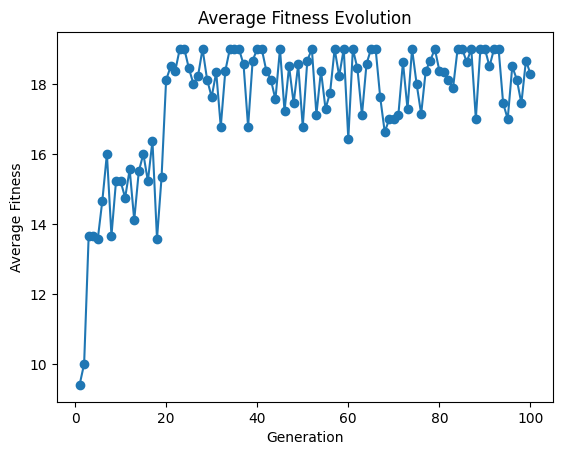

In [15]:
import matplotlib.pyplot as plt

def main():
    print("Knapsack Problem: Genetic Algorithm")

    global generations
    genomes = [initial_population(items) for _ in range(population_size)]

    best_solution = None
    best_profit = 0
    avg_fitness_history = []

    for generation in range(generations):
        fitness_list = fitness(genomes)

        if fitness_list:
            top_solution = max(fitness_list, key=lambda x: x[1])

            avg_fitness = sum(fit[1] for fit in fitness_list) / len(fitness_list)
            avg_fitness_history.append(avg_fitness)

            if top_solution[1] > best_profit:
                best_solution, best_profit = top_solution

            print(f"Generation {generation + 1}: Best Profit = {top_solution[1]}, Solution = {top_solution[0]}")
            print(f"Average Fitness {avg_fitness}")

        genomes = crossover(genomes)

    print(f"\nBest Overall Solution: {best_solution}\nProfit: {best_profit}")

    # Plot the average fitness over generations
    plt.plot(range(1, generations + 1), avg_fitness_history, marker="o", linestyle="-")
    plt.xlabel("Generation")
    plt.ylabel("Average Fitness")
    plt.title("Average Fitness Evolution")
    plt.show()


main()